In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("social_media_engagement_5000.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'social_media_engagement_5000.csv'

In [3]:
import os
os.getcwd()

'C:\\Users\\Vishal K'

In [5]:
import pandas as pd

df = pd.read_csv("social_media_engagement_5000.csv")

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [6]:
df.shape

(5000, 19)

In [7]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='str')

In [8]:
df.dtypes

user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object

In [9]:
df['posted_at'] = pd.to_datetime(df['posted_at'])

df['posted_at'].dtype

C:\Users\Vishal K\AppData\Local\Temp\ipykernel_15800\4218305723.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


dtype('<M8[us]')

In [10]:
df['posted_at'] = pd.to_datetime(df['posted_at'], dayfirst=True)

df['posted_at'].dtype

dtype('<M8[us]')

In [11]:
df.dtypes

user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
dtype: object

In [12]:
df.isnull().sum()

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

In [13]:
df['age'] = df['age'].fillna(df['age'].median())
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['shares'] = df['shares'].fillna(df['shares'].median())

In [14]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop_duplicates()

df.shape

(5000, 19)

In [17]:
df['gender'].value_counts()

gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

In [19]:
df[['likes', 'comments', 'shares']].agg(['min', 'max'])

,likes,comments,shares
min,10.0,0.0,0.0
max,19998.0,2999.0,1999.0


In [20]:
(df[['likes', 'comments', 'shares']] < 0).sum()

likes       0
comments    0
shares      0
dtype: int64

In [21]:
df.dtypes

user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
dtype: object

In [22]:
df['likes'] = df['likes'].astype(int)
df['comments'] = df['comments'].astype(int)
df['shares'] = df['shares'].astype(int)

df[['likes', 'comments', 'shares']].dtypes

likes       int64
comments    int64
shares      int64
dtype: object

In [23]:
df['hashtag_count'] = df['hashtags'].fillna('').apply(
    lambda x: len(x.split()) if x != '' else 0
)

df[['hashtags', 'hashtag_count']].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [24]:
df['sentiment'].value_counts()

sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

In [25]:
df.isnull().sum()

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
hashtag_count       0
dtype: int64

In [26]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [27]:
df.shape

(5000, 20)

In [28]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [29]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='str')

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   b

In [31]:
df.dtypes

user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                        int64
comments                     int64
shares                       int64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
hashtag_count                int64
dtype: object

In [32]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [33]:
df['post_type'].value_counts()

post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

In [34]:
df['post_type'].unique()

<ArrowStringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: str

In [35]:
df['post_type'].nunique()

4

In [36]:
numeric_df = df.select_dtypes(include='number')

correlation_matrix = numeric_df.corr()

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036323,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036323,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093521,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093521,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [37]:
df.groupby('post_type')['likes'].mean()

post_type
image    10104.852446
reel     10037.784879
text     10100.132530
video    10188.586122
Name: likes, dtype: float64

In [38]:
df.groupby('country')['impression_count'].mean()

country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64

In [39]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

df[['likes', 'comments', 'shares', 'engagement_score']].head()

,likes,comments,shares,engagement_score
0,7011,354,1157,8522
1,11750,2606,1807,16163
2,4862,344,955,6161
3,5350,1083,1049,7482
4,12682,2735,1300,16717


In [40]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score'],
      dtype='str')

In [41]:
df.groupby('post_type')['engagement_score'].mean()

post_type
image    12649.377706
reel     12524.014030
text     12613.228112
video    12664.580408
Name: engagement_score, dtype: float64

In [42]:
df.groupby('country')['engagement_rate'].mean()

country
Australia    1.324339
Brazil       1.540704
Canada       0.916659
France       1.146402
Germany      0.759000
India        0.655005
Japan        0.769623
UAE          1.112352
UK           0.850966
USA          0.576580
Name: engagement_rate, dtype: float64

In [43]:
df.groupby('sentiment')['engagement_score'].mean()

sentiment
negative    12731.483333
neutral     12448.149312
positive    12665.784322
Name: engagement_score, dtype: float64

In [44]:
df_part1 = df.iloc[:2500]
df_part2 = df.iloc[2500:]

print(df_part1.shape)
print(df_part2.shape)

(2500, 21)
(2500, 21)


In [45]:
combined_df = pd.concat([df_part1, df_part2])

combined_df.shape

(5000, 21)

In [46]:
stats_columns = ['likes', 'comments', 'shares', 'watch_time_sec',
                 'engagement_rate', 'follower_count']

stats_df = df[stats_columns]

stats_df.head()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,7011,354,1157,5726,0.190862,81734
1,11750,2606,1807,5947,0.201493,5963
2,4862,344,955,6946,0.137345,501783
3,5350,1083,1049,229,0.106195,480212
4,12682,2735,1300,4798,2.777372,383936


In [47]:
stats_df.mean()

likes               10106.982400
comments             1502.039800
shares               1002.910600
watch_time_sec       4014.503200
engagement_rate         0.964356
follower_count     393698.224800
dtype: float64

In [48]:
stats_df.median()

likes               10105.000000
comments             1497.000000
shares               1012.000000
watch_time_sec       4034.500000
engagement_rate         0.253896
follower_count     388982.000000
dtype: float64

In [49]:
stats_df.mode().head(1)

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,10105.0,1497.0,1012.0,916.0,0.006363,497502.0


In [50]:
stats_df.std()

likes                5702.293022
comments              856.393312
shares                570.855200
watch_time_sec       2308.096459
engagement_rate         5.318029
follower_count     230927.884535
dtype: float64

In [51]:
stats_df.var()

likes              3.251615e+07
comments           7.334095e+05
shares             3.258757e+05
watch_time_sec     5.327309e+06
engagement_rate    2.828143e+01
follower_count     5.332769e+10
dtype: float64

In [52]:
stats_df.quantile([0.25, 0.50, 0.75]

_IncompleteInputError: incomplete input (882732543.py, line 1)

In [53]:
stats_df.quantile([0.25, 0.50, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.0,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [54]:
stats_df.skew()

likes              -0.006886
comments            0.003802
shares             -0.014654
watch_time_sec     -0.018196
engagement_rate    18.781271
follower_count      0.041118
dtype: float64

In [55]:
stats_df.kurt()

likes               -1.149992
comments            -1.144375
shares              -1.146857
watch_time_sec      -1.195652
engagement_rate    482.991739
follower_count      -1.189474
dtype: float64

In [56]:
plt.scatter(df['likes'], df['impression_count'])

plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.title('Likes vs Impressions')

plt.show()

NameError: name 'plt' is not defined

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

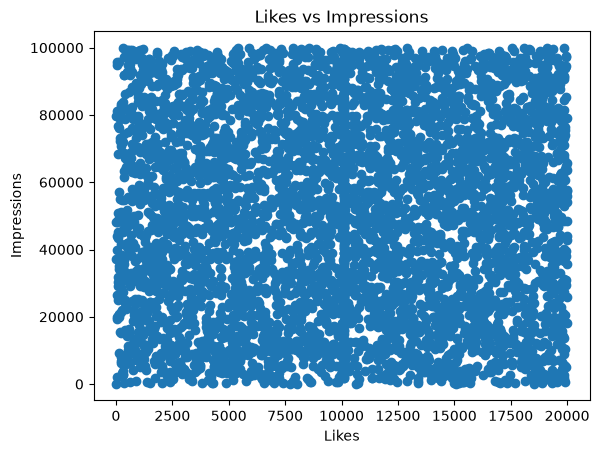

In [58]:
plt.scatter(df['likes'], df['impression_count'])

plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.title('Likes vs Impressions')

plt.show()

In [60]:
daily_engagement = df.groupby(df['posted_at'].dt.date)['engagement_rate'].mean()

daily_engagement.head()

posted_at
2022-01-01    3.304447
2022-01-02    0.890189
2022-01-03    8.083525
2022-01-04    0.157607
2022-01-05    0.516150
Name: engagement_rate, dtype: float64

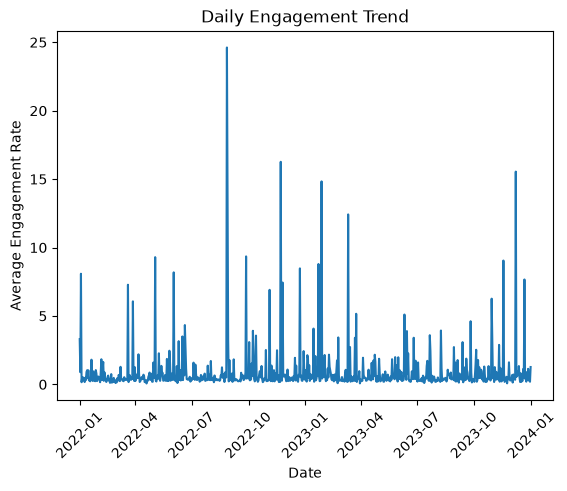

In [61]:
plt.plot(daily_engagement.index, daily_engagement.values)

plt.xlabel('Date')
plt.ylabel('Average Engagement Rate')
plt.title('Daily Engagement Trend')
plt.xticks(rotation=45)

plt.show()

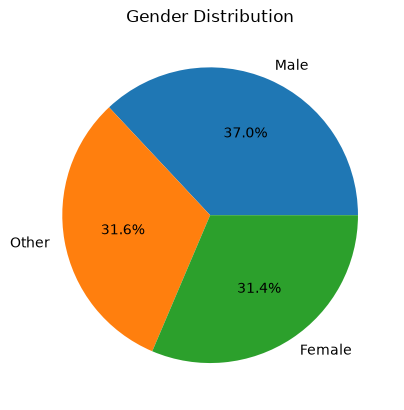

In [62]:
gender_counts = df['gender'].value_counts()

plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')

plt.title('Gender Distribution')

plt.show()

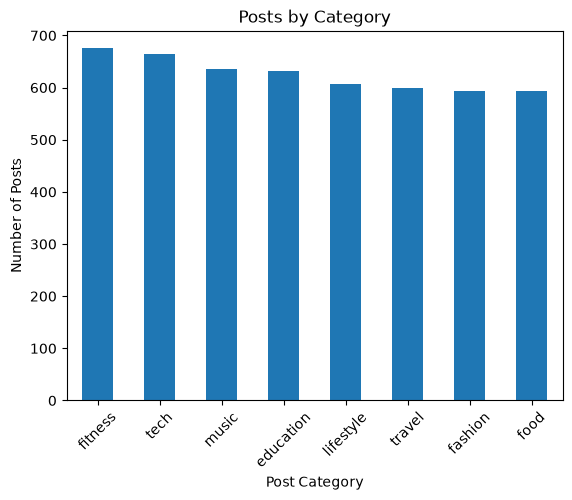

In [63]:
category_counts = df['post_category'].value_counts()

category_counts.plot(kind='bar')

plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')
plt.xticks(rotation=45)

plt.show()

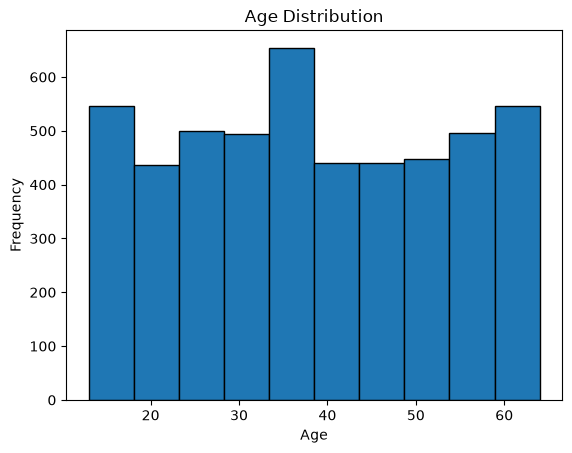

In [64]:
plt.hist(df['age'], bins=10, edgecolor='black')

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

plt.show()

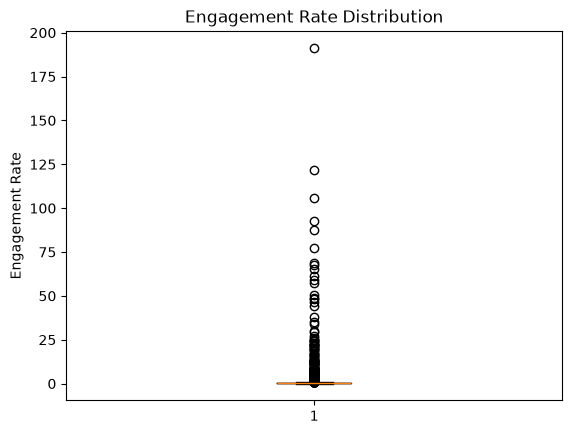

In [65]:
plt.boxplot(df['engagement_rate'])

plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')

plt.show()

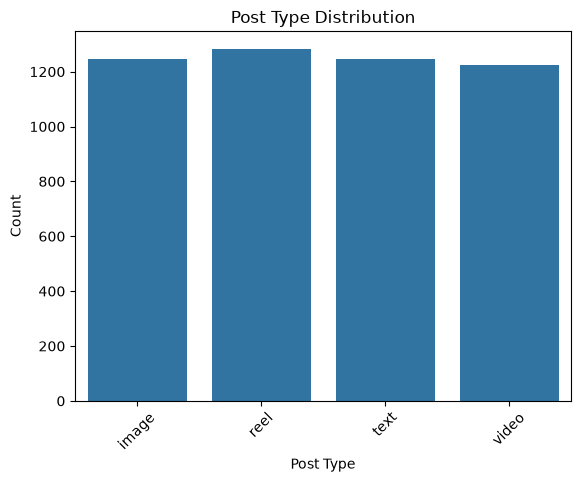

In [66]:
sns.countplot(x='post_type', data=df)

plt.xlabel('Post Type')
plt.ylabel('Count')
plt.title('Post Type Distribution')
plt.xticks(rotation=45)

plt.show()

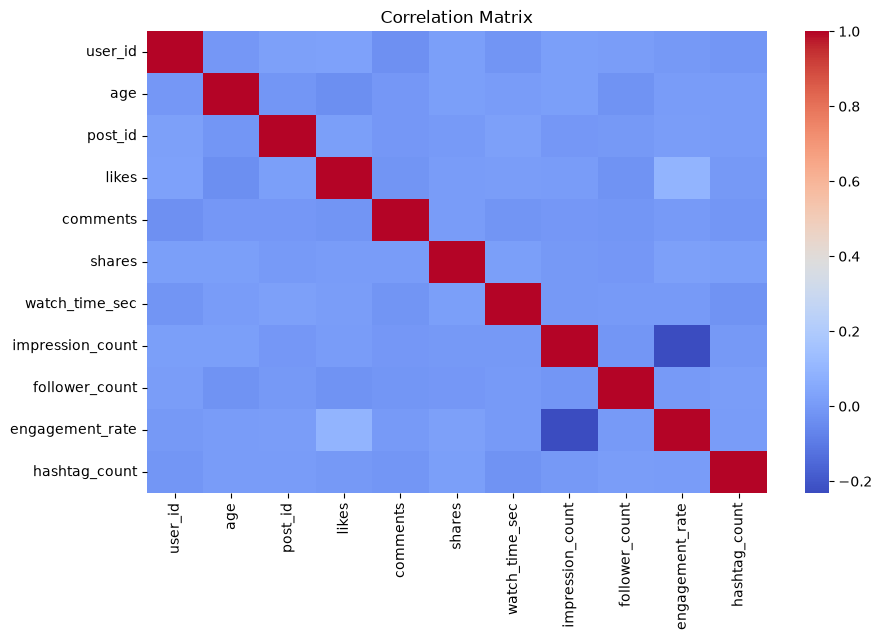

In [67]:
plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

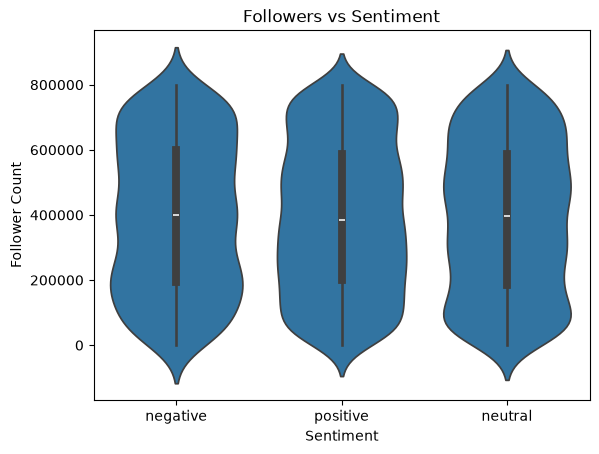

In [68]:
sns.violinplot(x='sentiment', y='follower_count', data=df)

plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.title('Followers vs Sentiment')

plt.show()

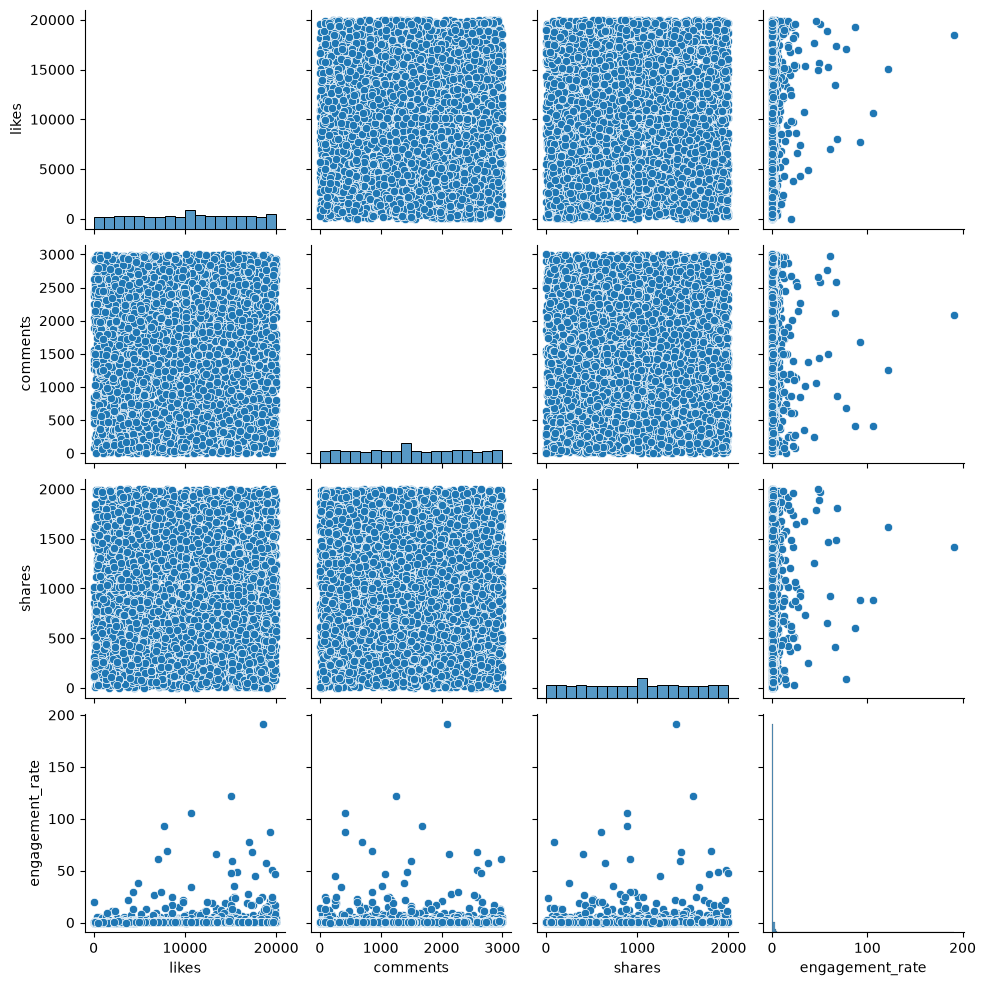

In [69]:
pair_data = df[['likes', 'comments', 'shares', 'engagement_rate']]

sns.pairplot(pair_data)

plt.show()

C:\Users\Public\Anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 64.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Public\Anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 59.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Public\Anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 56.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Public\Anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 68.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Public\Anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 63.3% of the p

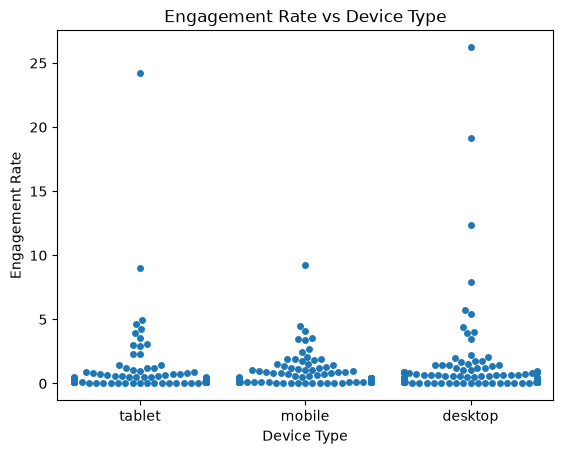

In [70]:
sample_df = df.sample(500, random_state=1)

sns.swarmplot(x='device_type', y='engagement_rate', data=sample_df)

plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate vs Device Type')

plt.show()

In [71]:
import plotly.express as px

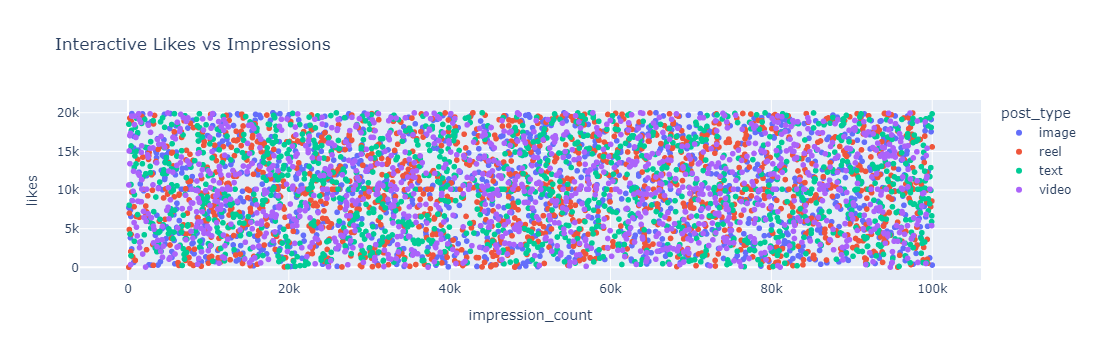

In [72]:
fig = px.scatter(
    df,
    x='impression_count',
    y='likes',
    color='post_type',
    title='Interactive Likes vs Impressions'
)

fig.show()

In [73]:
post_engagement = df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False)

post_engagement

post_type
video    1.122365
text     1.064549
image    0.895646
reel     0.783047
Name: engagement_rate, dtype: float64

In [74]:
category_engagement = df.groupby('post_category')['engagement_rate'].mean().sort_values(ascending=False)

category_engagement

post_category
food         1.358628
tech         1.160475
lifestyle    1.091019
music        0.888803
fitness      0.865628
education    0.844222
fashion      0.807109
travel       0.702223
Name: engagement_rate, dtype: float64

In [75]:
country_engagement = df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)

country_engagement

country
Brazil       1.540704
Australia    1.324339
France       1.146402
UAE          1.112352
Canada       0.916659
UK           0.850966
Japan        0.769623
Germany      0.759000
India        0.655005
USA          0.576580
Name: engagement_rate, dtype: float64

In [76]:
age_engagement = df.groupby('age')['engagement_rate'].mean()

age_engagement

age
13.0    0.455583
14.0    1.003067
15.0    0.714170
16.0    1.226848
17.0    0.858763
18.0    0.888391
19.0    0.676687
20.0    0.515541
21.0    0.452752
22.0    0.586786
23.0    0.922448
24.0    2.897327
25.0    1.041681
26.0    0.501467
27.0    0.775328
28.0    0.385081
29.0    1.110432
30.0    1.270129
31.0    0.440684
32.0    0.581710
33.0    1.277557
34.0    0.557236
35.0    1.521596
36.0    0.609569
37.0    0.494109
38.0    1.035114
39.0    0.436184
40.0    0.930504
41.0    1.540070
42.0    1.350772
43.0    0.566439
44.0    0.795102
45.0    0.513521
46.0    0.663994
47.0    1.402015
48.0    1.675878
49.0    0.999235
50.0    1.552627
51.0    2.397295
52.0    0.867426
53.0    0.707924
54.0    1.002622
55.0    2.599106
56.0    0.524008
57.0    0.919751
58.0    0.435130
59.0    0.495578
60.0    0.759586
61.0    0.553854
62.0    1.005127
63.0    1.303909
64.0    0.402533
Name: engagement_rate, dtype: float64

In [77]:
df[['age', 'engagement_rate']].corr()

,age,engagement_rate
age,1.000000,0.008039
engagement_rate,0.008039,1.000000


In [78]:
verified_performance = df.groupby('is_verified')['engagement_rate'].mean()

verified_performance

is_verified
False    0.954744
True     1.054250
Name: engagement_rate, dtype: float64

In [79]:
df['post_hour'] = df['posted_at'].dt.hour

hourly_impressions = df.groupby('post_hour')['impression_count'].mean().sort_values(ascending=False)

hourly_impressions

post_hour
0    50013.7328
Name: impression_count, dtype: float64

In [81]:
device_watch_time = df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False)

device_watch_time

device_type
mobile     4087.830760
tablet     3979.736429
desktop    3974.792521
Name: watch_time_sec, dtype: float64

In [82]:
sentiment_performance = df.groupby('sentiment')['engagement_rate'].mean().sort_values(ascending=False)

sentiment_performance

sentiment
negative    1.038486
neutral     0.991170
positive    0.919744
Name: engagement_rate, dtype: float64

In [83]:
sentiment_behavior = df.groupby('sentiment')[
    ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate']
].mean()

sentiment_behavior

,likes,comments,shares,watch_time_sec,engagement_rate
sentiment,,,,,
negative,10208.081250,1516.094792,1007.307292,4054.639583,1.038486
neutral,9923.180092,1528.404060,996.565160,4031.823183,0.991170
positive,10180.046956,1480.650617,1005.086749,3988.646240,0.919744
